# MLP — Multilayer Perceptron

Red neuronal densa (fully-connected) para predecir la media de retornos en la ventana de salida.

- Entrada: ventana de `input_w` días × 23 tickers → se aplana a un vector de tamaño `input_w * 23`.
- Salida: 23 valores (uno por ticker), regresión directa.
- Pérdida: **MAE** (coherente con la evaluación usada en el notebook de regresión lineal).

In [1]:
import sys
import mlflow
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

EXPERIMENT_NAME = "Red_Neuronal_Densa"
mlflow.set_experiment(EXPERIMENT_NAME)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import keras as keras
from keras.models import Sequential
from keras.layers import Dense, Input

from sklearn.metrics import mean_absolute_error

from util import get_train_test, RANDOM_SEED, compare_to_benchmark, plot_benchmark_comparison, plot_training_curve

np.random.seed(RANDOM_SEED)
keras.utils.set_random_seed(RANDOM_SEED)

/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Cargamos datos y aplanamos la ventana de entrada

In [2]:
def load_flat_data(input_window_size, output_window_size):
    d = get_train_test(input_window_size=input_window_size, output_window_size=output_window_size)

    X_train = d.X_train.reshape(d.X_train.shape[0], -1)
    X_test  = d.X_test.reshape(d.X_test.shape[0], -1)
    y_train = d.y_train
    y_test  = d.y_test

    val_size = int(0.10 * X_train.shape[0])
    X_val   = X_train[-val_size:]
    y_val   = y_train[-val_size:]
    X_train = X_train[:-val_size]
    y_train = y_train[:-val_size]

    return X_train, y_train, X_val, y_val, X_test, y_test


input_window_size = 30
output_window_size = 5

X_train_flat, y_train_seq, X_val_flat, y_val_seq, X_test_flat, y_test_seq = load_flat_data(input_window_size, output_window_size)

print(f"X_train_flat: {X_train_flat.shape}")
print(f"y_train_seq:  {y_train_seq.shape}")
print(f"X_val_flat:   {X_val_flat.shape}")
print(f"y_val_seq:    {y_val_seq.shape}")
print(f"X_test_flat:  {X_test_flat.shape}")
print(f"y_test_seq:   {y_test_seq.shape}")

X_train_flat: (13082, 690)
y_train_seq:  (13082, 23)
X_val_flat:   (1453, 690)
y_val_seq:    (1453, 23)
X_test_flat:  (1616, 690)
y_test_seq:   (1616, 23)


## Definición del modelo

MLP muy simple: una capa oculta densa con 100 neuronas ReLU y una capa de salida lineal con tantas unidades como tickers.

In [3]:
num_neurons = 100
act_function = 'relu'

# DEFINICION DEL MODELO: añadimos capas una a una
model = Sequential()
model.add(Input(shape=(X_train_flat.shape[1],)))
model.add(Dense(num_neurons, activation=act_function))
model.add(Dense(y_train_seq.shape[1]))

# DEFINICION DE FUNCIÓN DE COSTE Y OPTIMIZADOR
model.compile(loss='mean_absolute_error', optimizer='Adam')

model.summary()

run_name = f"{EXPERIMENT_NAME}_input{input_window_size}_output{output_window_size}_1000epochs"
#Si ya existe un run con el mismo nombre, lo eliminamos para evitar conflictos
existing_runs = mlflow.search_runs(filter_string=f'tags.mlflow.runName = "{run_name}"')
if not existing_runs.empty:
    mlflow.delete_run(existing_runs.iloc[0].run_id)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 100)            │        69,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 23)             │         2,323 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,423 (279.00 KB)

 Trainable params: 71,423 (279.00 KB)

 Non-trainable params: 0 (0.00 B)

## Entrenamiento

In [4]:
#Por defecto, el bach_size es 32
batch_size = 32
hist = model.fit(X_train_flat, y_train_seq,validation_data=(X_val_flat, y_val_seq),epochs=1000, batch_size=batch_size)

Epoch 1/1000
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 638us/step - loss: 0.0062 - val_loss: 0.0042
Epoch 2/1000
409/409 ━━━━━━━━━━━━━━━━━━━━ 0s 728us/step - loss: 0.0055 - val_loss: 0.0043
Epoch 3/1000
409/409 ━━━━━━━━━━━━━━━━━━━━ 0s 514us/step - loss: 0.0055 - val_loss: 0.0043
Epoch 4/1000
409/409 ━━━━━━━━━━━━━━━━━━━━ 0s 508us/step - loss: 0.0055 - val_loss: 0.0043
Epoch 5/1000
409/409 ━━━━━━━━━━━━━━━━━━━━ 0s 555us/step - loss: 0.0054 - val_loss: 0.0043
Epoch 6/1000
409/409 ━━━━━━━━━━━━━━━━━━━━ 0s 512us/step - loss: 0.0054 - val_loss: 0.0043
Epoch 7/1000
409/409 ━━━━━━━━━━━━━━━━━━━━ 0s 509us/step - loss: 0.0054 - val_loss: 0.0042
Epoch 8/1000
409/409 ━━━━━━━━━━━━━━━━━━━━ 0s 502us/step - loss: 0.0053 - val_loss: 0.0043
Epoch 9/1000
409/409 ━━━━━━━━━━━━━━━━━━━━ 0s 503us/step - loss: 0.0053 - val_loss: 0.0043
Epoch 10/1000
409/409 ━━━━━━━━━━━━━━━━━━━━ 0s 502us/step - loss: 0.0053 - val_loss: 0.0043
Epoch 11/1000
409/409 ━━━━━━━━━━━━━━━━━━━━ 0s 515us/step - loss: 0.0053 - val_loss: 0.0042
Epoch 12

## Curva de pérdida

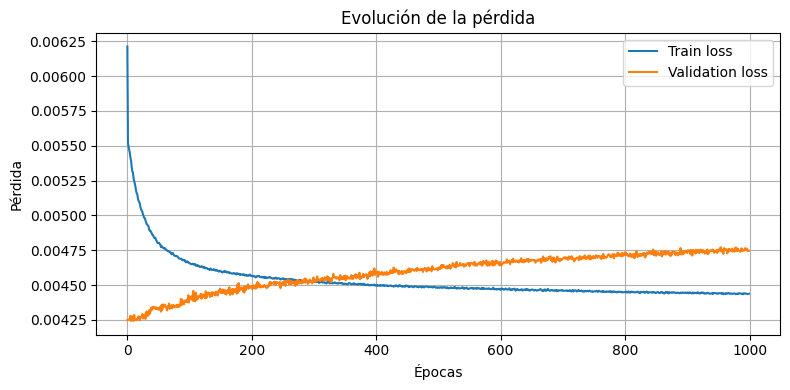

In [5]:
fig = plot_training_curve(hist, show=True)

## Evaluación final (MAE train y test)

In [7]:
with mlflow.start_run(run_name=run_name):
    y_pred_train = model.predict(X_train_flat, verbose=0)
    y_pred_val   = model.predict(X_val_flat, verbose=0)
    y_pred_test  = model.predict(X_test_flat, verbose=0)

    mae_train = mean_absolute_error(y_train_seq, y_pred_train)
    mae_val   = mean_absolute_error(y_val_seq, y_pred_val)
    mae_test  = mean_absolute_error(y_test_seq,  y_pred_test)

    # Registramos las métricas de pérdida de entrenamiento y validación en MLflow para cada época
    for epoch, (train_loss, val_loss) in enumerate(zip(hist.history["loss"], hist.history["val_loss"])):
        mlflow.log_metric("train_loss", train_loss, step=epoch)
        mlflow.log_metric("val_loss", val_loss, step=epoch)

    mlflow.log_figure(fig, "plots/loss_curve.png")
    plt.close(fig)

    #Registramos los parametros y métricas en MLflow
    mlflow.log_param("model_type", "Dense_Neural_Network")
    mlflow.log_param("hidden_layers", 1)
    mlflow.log_param("neurons", num_neurons)
    mlflow.log_param("activation", act_function)
    mlflow.log_param("input_window_size", input_window_size)
    mlflow.log_param("output_window_size", output_window_size)
    mlflow.log_param("num_features", y_train_seq.shape[1])
    mlflow.log_param("num_samples", X_train_flat.shape[0])
    mlflow.log_param("n_params", model.count_params())
    #Guardamos también el número de épocas como parámetro
    mlflow.log_param("epochs", len(hist.history["loss"]))
    #Guardamos también el tamaño del batch como parámetro
    mlflow.log_param("batch_size", batch_size)

    mlflow.log_metric("train_mae", mae_train)
    mlflow.log_metric("val_mae", mae_val)
    mlflow.log_metric("test_mae", mae_test)

    # Registramos el modelo entrenado en MLflow
    mlflow.keras.log_model(model, name="dense_nn_model")

    print(f"MAE train: {mae_train:.6f}")
    print(f"MAE val:    {mae_val:.6f}")
    print(f"MAE test:  {mae_test:.6f}")

2026/04/28 17:28:40 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


MAE train: 0.004484
MAE val:    0.004746
MAE test:  0.007928


## Grid de ventanas

Mismo barrido que en `regresion_lineal.ipynb` para comparar MLP vs. regresión lineal.

In [8]:
input_windows = [5, 10, 30, 90]
output_windows = [1, 5, 30, 90]

results = []

batch_size = 128
num_neurons = 100
act_function = 'relu'

for in_w in input_windows:
    for out_w in output_windows:
        run_name = f"{EXPERIMENT_NAME}_input{in_w}_output{out_w}"
        existing_runs = mlflow.search_runs(filter_string=f'tags.mlflow.runName = "{run_name}"')
        if not existing_runs.empty:
            mlflow.delete_run(existing_runs.iloc[0].run_id)
        with mlflow.start_run(run_name=run_name):
            X_tr, y_tr, X_val, y_val, X_te, y_te = load_flat_data(in_w, out_w)

            keras.utils.set_random_seed(RANDOM_SEED)
            m = Sequential()
            m.add(Input(shape=(X_tr.shape[1],)))
            m.add(Dense(num_neurons, activation=act_function))
            m.add(Dense(y_tr.shape[1]))
            m.compile(loss='mean_absolute_error', optimizer='Adam')

            history = m.fit(X_tr, y_tr, validation_data=(X_val, y_val), epochs=20, batch_size=batch_size, verbose=0)

            for epoch, (train_loss, val_loss) in enumerate(zip(history.history["loss"], history.history["val_loss"])):
                mlflow.log_metric("train_loss", train_loss, step=epoch)
                mlflow.log_metric("val_loss", val_loss, step=epoch)

            fig = plot_training_curve(history)
            mlflow.log_figure(fig, "plots/loss_curve.png")
            plt.close(fig)

            mae_tr = mean_absolute_error(y_tr, m.predict(X_tr, verbose=0))
            mae_val = mean_absolute_error(y_val, m.predict(X_val, verbose=0))
            mae_te = mean_absolute_error(y_te, m.predict(X_te, verbose=0))

            mlflow.log_param("model_type", "Dense_Neural_Network")
            mlflow.log_param("hidden_layers", 1)
            mlflow.log_param("neurons", num_neurons)
            mlflow.log_param("activation", act_function)
            mlflow.log_param("input_window_size", in_w)
            mlflow.log_param("output_window_size", out_w)
            mlflow.log_param("n_params", m.count_params())
            mlflow.log_param("num_samples", X_tr.shape[0])
            mlflow.log_param("epochs", len(history.history["loss"]))
            mlflow.log_param("batch_size", batch_size)

            mlflow.log_metric("train_mae", mae_tr)
            mlflow.log_metric("val_mae", mae_val)
            mlflow.log_metric("test_mae", mae_te)

            mlflow.keras.log_model(m, name="dense_nn_model")

            results.append({"input_window": in_w, "output_window": out_w,
                            "MAE_train": mae_tr, "MAE_test": mae_te})
            print(f"input={in_w:>3}d, output={out_w:>3}d  ->  MAE train = {mae_tr:.6f} | MAE test = {mae_te:.6f}")

results_df = pd.DataFrame(results)
results_df

2026/04/28 17:28:45 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


input=  5d, output=  1d  ->  MAE train = 0.011300 | MAE test = 0.012618


2026/04/28 17:28:50 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


input=  5d, output=  5d  ->  MAE train = 0.005301 | MAE test = 0.005698


2026/04/28 17:28:55 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


...

2026/04/28 17:30:03 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


input= 90d, output= 30d  ->  MAE train = 0.002123 | MAE test = 0.002444


2026/04/28 17:30:09 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


input= 90d, output= 90d  ->  MAE train = 0.001268 | MAE test = 0.001395


,input_window,output_window,MAE_train,MAE_test
0,5,1,0.011300,0.012618
1,5,5,0.005301,0.005698
2,5,30,0.002198,0.002400
3,5,90,0.001268,0.001348
4,10,1,0.010938,0.013072
5,10,5,0.005193,0.005891
6,10,30,0.002175,0.002446
7,10,90,0.001274,0.001348
8,30,1,0.010071,0.013436
9,30,5,0.004855,0.005976


## Matrices y heatmaps

In [9]:
mae_train_matrix = results_df.pivot(index="input_window", columns="output_window", values="MAE_train")
mae_test_matrix  = results_df.pivot(index="input_window", columns="output_window", values="MAE_test")

print("MAE — TRAIN")
display(mae_train_matrix)
print("MAE — TEST")
display(mae_test_matrix)
print("Gap (test - train)")
display(mae_test_matrix - mae_train_matrix)

MAE — TRAIN


output_window,1,5,30,90
input_window,,,,
5,0.011300,0.005301,0.002198,0.001268
10,0.010938,0.005193,0.002175,0.001274
30,0.010071,0.004855,0.002164,0.001269
90,0.009010,0.004575,0.002123,0.001268


MAE — TEST


output_window,1,5,30,90
input_window,,,,
5,0.012618,0.005698,0.002400,0.001348
10,0.013072,0.005891,0.002446,0.001348
30,0.013436,0.005976,0.002469,0.001383
90,0.013672,0.006023,0.002444,0.001395


Gap (test - train)


output_window,1,5,30,90
input_window,,,,
5,0.001318,0.000397,0.000202,0.000080
10,0.002134,0.000698,0.000271,0.000075
30,0.003365,0.001121,0.000304,0.000114
90,0.004662,0.001449,0.000321,0.000128


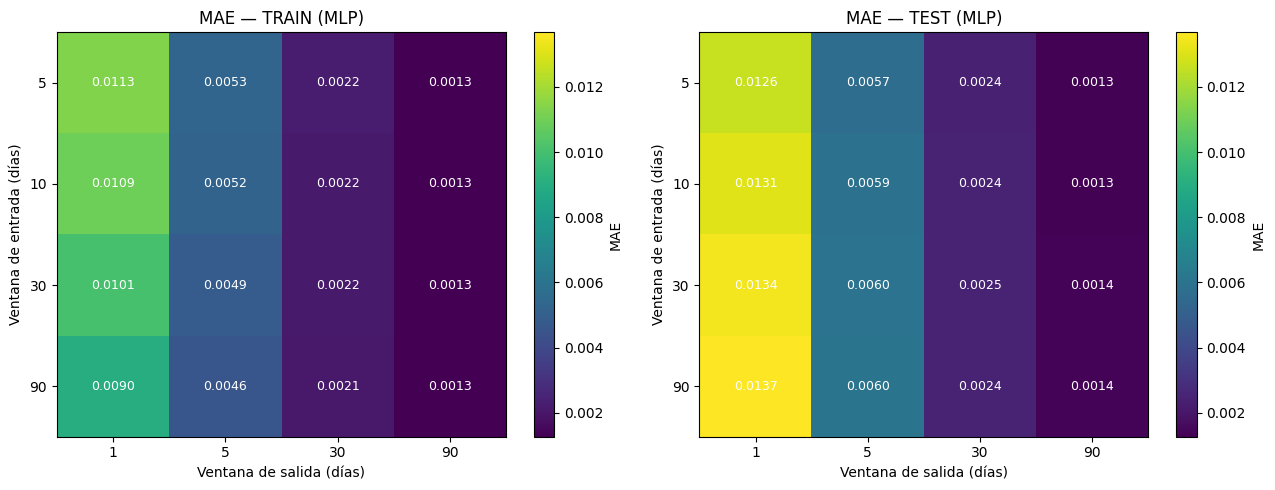

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

vmin = min(mae_train_matrix.values.min(), mae_test_matrix.values.min())
vmax = max(mae_train_matrix.values.max(), mae_test_matrix.values.max())

for ax, matrix, title in [
    (axes[0], mae_train_matrix, "MAE — TRAIN (MLP)"),
    (axes[1], mae_test_matrix,  "MAE — TEST (MLP)"),
]:
    im = ax.imshow(matrix.values, cmap="viridis", aspect="auto", vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(matrix.columns)))
    ax.set_xticklabels(matrix.columns)
    ax.set_yticks(range(len(matrix.index)))
    ax.set_yticklabels(matrix.index)
    ax.set_xlabel("Ventana de salida (días)")
    ax.set_ylabel("Ventana de entrada (días)")
    ax.set_title(title)
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            ax.text(j, i, f"{matrix.values[i, j]:.4f}",
                    ha="center", va="center", color="white", fontsize=9)
    plt.colorbar(im, ax=ax, label="MAE")

plt.tight_layout()
plt.show()

## Comparación con el benchmark de regresión lineal

Usamos `compare_to_benchmark` y `plot_benchmark_comparison` de `util.py` para ver, celda a celda del grid, si el MLP mejora o empeora el MAE test respecto a la regresión lineal.

- `delta < 0` (azul): el MLP mejora al benchmark.
- `delta > 0` (rojo): el MLP empeora al benchmark.

,input_window,output_window,MAE_test,MAE_test_benchmark,delta,pct_delta
0,5,1,0.012618,0.012384,0.000235,1.894049
1,5,5,0.005698,0.005625,0.000073,1.296463
2,5,30,0.002400,0.002340,0.000060,2.565082
3,5,90,0.001348,0.001271,0.000076,5.992340
4,10,1,0.013072,0.012554,0.000517,4.121904
5,10,5,0.005891,0.005698,0.000193,3.390573
6,10,30,0.002446,0.002358,0.000088,3.710606
7,10,90,0.001348,0.001282,0.000066,5.153843
8,30,1,0.013436,0.012924,0.000512,3.961532
9,30,5,0.005976,0.005877,0.000100,1.697109


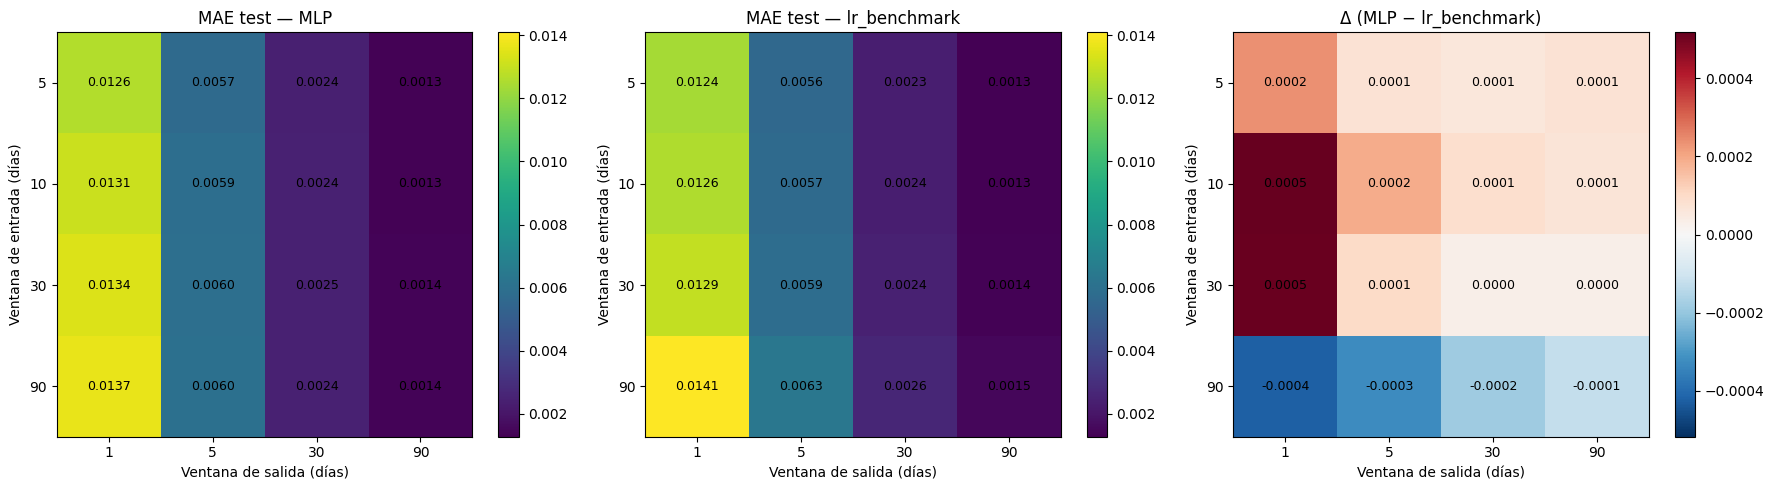

In [11]:
comparison = compare_to_benchmark(results_df, benchmark="lr_benchmark")
display(comparison)

plot_benchmark_comparison(results_df, benchmark="lr_benchmark", model_name="MLP")
plt.show()

## Búsqueda de hiperparámetros

Hasta aquí la arquitectura (1 capa · 100 ReLU), el optimizador (Adam lr=1e-3) y el batch han sido fijos. ¿Son los mejores HPs para minimizar el MAE? Lo buscamos en **dos etapas** sobre una ventana fija `(input=30, output=5)`:

1. **Arquitectura**: `hidden_layers × neurons × activation`.
2. **Entrenamiento**: `learning_rate × batch_size`, con la arquitectura ganadora.

Reglas clave:
- La selección se hace con **MAE de validación**. El test **no se toca** durante la búsqueda — solo al final con el ganador. Así el benchmark de comparación sigue siendo limpio.
- `EarlyStopping(patience=10, restore_best_weights=True)` para no malgastar epochs.
- `keras.utils.set_random_seed(RANDOM_SEED)` antes de cada fit, así las diferencias entre configuraciones no son ruido.

In [12]:
from util import load_benchmark
import itertools
from keras.callbacks import EarlyStopping
from keras.optimizers import Adam

INPUT_W, OUTPUT_W = 30, 5

X_tr, y_tr, X_val, y_val, X_te, y_te = load_flat_data(INPUT_W, OUTPUT_W)

print(f"Ventana fija: input={INPUT_W}, output={OUTPUT_W}")
print(f"X_tr: {X_tr.shape}  y_tr: {y_tr.shape}")
print(f"X_val: {X_val.shape}  y_val: {y_val.shape}")
print(f"X_te: {X_te.shape}  y_te: {y_te.shape}")

def build_mlp(hidden_layers: int, neurons: int, activation: str, lr: float = 1e-3):
    """Construye un MLP con N capas ocultas del mismo tamaño y compila con Adam+MAE."""
    keras.utils.set_random_seed(RANDOM_SEED)
    m = Sequential()
    m.add(Input(shape=(X_tr.shape[1],)))
    for _ in range(hidden_layers):
        m.add(Dense(neurons, activation=activation))
    m.add(Dense(y_tr.shape[1]))
    m.compile(loss="mean_absolute_error", optimizer=Adam(learning_rate=lr))
    return m

def fit_eval(model, batch_size: int = 128, epochs: int = 200, patience: int = 10, verbose: int = 0):
    """Entrena con EarlyStopping y devuelve MAE_train, MAE_val, MAE_test, history."""
    es = EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True)
    h = model.fit(X_tr, y_tr, validation_data=(X_val, y_val), epochs=epochs,
                  batch_size=batch_size, callbacks=[es], verbose=verbose)
    mae_tr  = mean_absolute_error(y_tr,  model.predict(X_tr,  verbose=0))
    mae_val = mean_absolute_error(y_val, model.predict(X_val, verbose=0))
    mae_te  = mean_absolute_error(y_te,  model.predict(X_te,  verbose=0))
    return mae_tr, mae_val, mae_te, h

Ventana fija: input=30, output=5
X_tr: (13082, 690)  y_tr: (13082, 23)
X_val: (1453, 690)  y_val: (1453, 23)
X_te: (1616, 690)  y_te: (1616, 23)


### Etapa 1 — arquitectura

18 combinaciones: `hidden_layers ∈ {1,2,3}` · `neurons ∈ {32,100,200}` · `activation ∈ {relu, tanh}`. Adam lr=1e-3, batch=128.

In [13]:
arch_grid = list(itertools.product([1, 2, 3], [32, 100, 200], ["relu", "tanh"]))

results_arch = []
batch_size = 128
for hl, n, act in arch_grid:
    run_name = f"{EXPERIMENT_NAME}_arch_layers{hl}_neurons{n}_{act}_input{INPUT_W}_output{OUTPUT_W}"
    existing_runs = mlflow.search_runs(filter_string=f'tags.mlflow.runName = "{run_name}"')
    if not existing_runs.empty:
        mlflow.delete_run(existing_runs.iloc[0].run_id)

    with mlflow.start_run(run_name=run_name):
        model = build_mlp(hl, n, act, lr=1e-3)
        mae_tr, mae_val, mae_te, h = fit_eval(model, batch_size=batch_size)

        for epoch, (train_loss, val_loss) in enumerate(zip(h.history["loss"], h.history["val_loss"])):
            mlflow.log_metric("train_loss", train_loss, step=epoch)
            mlflow.log_metric("val_loss", val_loss, step=epoch)

        fig = plot_training_curve(h)
        mlflow.log_figure(fig, "plots/loss_curve.png")
        plt.close(fig)

        mlflow.log_param("model_type", "Dense_Neural_Network")
        mlflow.log_param("hidden_layers", hl)
        mlflow.log_param("neurons", n)
        mlflow.log_param("activation", act)
        mlflow.log_param("learning_rate", 1e-3)
        mlflow.log_param("batch_size", batch_size)
        mlflow.log_param("input_window_size", INPUT_W)
        mlflow.log_param("output_window_size", OUTPUT_W)
        mlflow.log_param("num_features", y_tr.shape[1])
        mlflow.log_param("n_params", model.count_params())
        mlflow.log_param("epochs", len(h.history["loss"]))

        mlflow.log_metric("train_mae", mae_tr)
        mlflow.log_metric("val_mae", mae_val)
        mlflow.log_metric("test_mae", mae_te)

        mlflow.keras.log_model(model, "dense_nn_model")

        results_arch.append({
            "hidden_layers": hl, "neurons": n, "activation": act,
            "MAE_train": mae_tr, "MAE_val": mae_val, "MAE_test": mae_te,
            "epochs": len(h.history["loss"]), "n_params": model.count_params(),
        })
        print(f"layers={hl} neurons={n:>3} act={act:<4}  ->  MAE val={mae_val:.6f} | train={mae_tr:.6f} | test={mae_te:.6f} | epochs={len(h.history['loss']):>3}")

results_arch_df = pd.DataFrame(results_arch).sort_values("MAE_val").reset_index(drop=True)
results_arch_df.head(10)

2026/04/28 17:30:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/28 17:30:14 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


layers=1 neurons= 32 act=relu  ->  MAE val=0.004172 | train=0.005481 | test=0.005677 | epochs= 12


2026/04/28 17:30:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/28 17:30:20 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


layers=1 neurons= 32 act=tanh  ->  MAE val=0.004270 | train=0.005321 | test=0.005759 | epochs= 39


2026/04/28 17:30:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/28 17:30:25 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


...

2026/04/28 17:31:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/28 17:31:42 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


layers=3 neurons=200 act=relu  ->  MAE val=0.004170 | train=0.005482 | test=0.005595 | epochs= 11


2026/04/28 17:31:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/28 17:31:51 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


layers=3 neurons=200 act=tanh  ->  MAE val=0.004388 | train=0.005479 | test=0.005884 | epochs= 37


,hidden_layers,neurons,activation,MAE_train,MAE_val,MAE_test,epochs,n_params
0,3,32,relu,0.005478,0.004166,0.005607,13,24983
1,3,100,relu,0.005466,0.004169,0.005604,13,91623
2,2,100,relu,0.005473,0.004170,0.005621,11,81523
3,3,200,relu,0.005482,0.004170,0.005595,11,223223
4,2,32,relu,0.005488,0.004171,0.005643,11,23927
5,2,200,relu,0.005462,0.004172,0.005604,11,183023
6,1,32,relu,0.005481,0.004172,0.005677,12,22871
7,1,100,relu,0.005332,0.004178,0.005791,15,71423
8,1,200,relu,0.005384,0.004188,0.005874,12,142823
9,3,32,tanh,0.005478,0.004229,0.005689,13,24983


### Etapa 2 — entrenamiento

Fijamos la **arquitectura ganadora** de la etapa 1 y barremos `learning_rate ∈ {1e-2, 1e-3, 1e-4}` · `batch_size ∈ {64, 128, 256}`.

In [15]:
best_arch = results_arch_df.iloc[0]
print(f"Mejor arquitectura: layers={int(best_arch.hidden_layers)}  neurons={int(best_arch.neurons)}  activation={best_arch.activation}")
print(f"  MAE val = {best_arch.MAE_val:.6f}")

train_grid = list(itertools.product([1e-2, 1e-3, 1e-4], [64, 128, 256]))

results_train = []
for lr, bs in train_grid:
    run_name = f"{EXPERIMENT_NAME}_train_lr{lr:.0e}_batch{bs}_input{INPUT_W}_output{OUTPUT_W}"
    existing_runs = mlflow.search_runs(filter_string=f'tags.mlflow.runName = "{run_name}"')
    if not existing_runs.empty:
        mlflow.delete_run(existing_runs.iloc[0].run_id)

    with mlflow.start_run(run_name=run_name):
        model = build_mlp(int(best_arch.hidden_layers), int(best_arch.neurons),
                          best_arch.activation, lr=lr)
        mae_tr, mae_val, mae_te, h = fit_eval(model, batch_size=bs)

        for epoch, (train_loss, val_loss) in enumerate(zip(h.history["loss"], h.history["val_loss"])):
            mlflow.log_metric("train_loss", train_loss, step=epoch)
            mlflow.log_metric("val_loss", val_loss, step=epoch)

        fig = plot_training_curve(h)
        mlflow.log_figure(fig, "plots/loss_curve.png")
        plt.close(fig)

        mlflow.log_param("model_type", "Dense_Neural_Network")
        mlflow.log_param("hidden_layers", int(best_arch.hidden_layers))
        mlflow.log_param("neurons", int(best_arch.neurons))
        mlflow.log_param("activation", best_arch.activation)
        mlflow.log_param("learning_rate", lr)
        mlflow.log_param("batch_size", bs)
        mlflow.log_param("input_window_size", INPUT_W)
        mlflow.log_param("output_window_size", OUTPUT_W)
        mlflow.log_param("num_features", y_tr.shape[1])
        mlflow.log_param("n_params", model.count_params())
        mlflow.log_param("epochs", len(h.history["loss"]))

        mlflow.log_metric("train_mae", mae_tr)
        mlflow.log_metric("val_mae", mae_val)
        mlflow.log_metric("test_mae", mae_te)

        mlflow.keras.log_model(model, "dense_nn_model")

        results_train.append({
            "learning_rate": lr, "batch_size": bs,
            "MAE_train": mae_tr, "MAE_val": mae_val, "MAE_test": mae_te,
            "epochs": len(h.history["loss"]),
        })
        print(f"lr={lr:.0e} batch={bs:>3}  ->  MAE val={mae_val:.6f} | train={mae_tr:.6f} | test={mae_te:.6f} | epochs={len(h.history['loss']):>3}")

results_train_df = pd.DataFrame(results_train).sort_values("MAE_val").reset_index(drop=True)
results_train_df

Mejor arquitectura: layers=3  neurons=32  activation=relu
  MAE val = 0.004166


2026/04/28 19:43:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/28 19:43:07 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


lr=1e-02 batch= 64  ->  MAE val=0.004284 | train=0.005570 | test=0.005668 | epochs= 23


2026/04/28 19:43:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/28 19:43:12 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


lr=1e-02 batch=128  ->  MAE val=0.004297 | train=0.005581 | test=0.005695 | epochs= 11


...

2026/04/28 19:43:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/28 19:43:41 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


lr=1e-04 batch=128  ->  MAE val=0.004156 | train=0.005474 | test=0.005629 | epochs= 16


2026/04/28 19:43:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/28 19:43:46 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


lr=1e-04 batch=256  ->  MAE val=0.004158 | train=0.005470 | test=0.005635 | epochs= 21


,learning_rate,batch_size,MAE_train,MAE_val,MAE_test,epochs
0,0.0010,256,0.005477,0.004151,0.005599,11
1,0.0001,64,0.005479,0.004153,0.005626,13
2,0.0001,128,0.005474,0.004156,0.005629,16
3,0.0001,256,0.005470,0.004158,0.005635,21
4,0.0010,128,0.005478,0.004166,0.005607,13
5,0.0010,64,0.005503,0.004188,0.005624,11
6,0.0100,256,0.005534,0.004238,0.005646,11
7,0.0100,64,0.005570,0.004284,0.005668,23
8,0.0100,128,0.005581,0.004297,0.005695,11


### Retrain y evaluación final en test

Con los HPs ganadores entrenamos una última vez y evaluamos **por primera vez en test**. Lo comparamos contra el MLP base (capa única de 100 ReLU, batch 128, sin early stopping) y contra la regresión lineal en esa misma ventana.

In [16]:
best_train = results_train_df.iloc[0]
print("Configuración ganadora:")
print(f"  layers        = {int(best_arch.hidden_layers)}")
print(f"  neurons       = {int(best_arch.neurons)}")
print(f"  activation    = {best_arch.activation}")
print(f"  learning_rate = {best_train.learning_rate:.0e}")
print(f"  batch_size    = {int(best_train.batch_size)}")

best_model = build_mlp(int(best_arch.hidden_layers), int(best_arch.neurons),
                       best_arch.activation, lr=float(best_train.learning_rate))
mae_tr_best, mae_val_best, mae_te_best, ep_best = fit_eval(best_model, batch_size=int(best_train.batch_size))

# Referencias para esta misma ventana (30, 5)
mlp_base_row = results_df[(results_df.input_window == INPUT_W) & (results_df.output_window == OUTPUT_W)].iloc[0]
linreg_bench = load_benchmark("lr_benchmark")
linreg_row = linreg_bench[(linreg_bench.input_window == INPUT_W) & (linreg_bench.output_window == OUTPUT_W)].iloc[0]

summary = pd.DataFrame([
    {"modelo": "Regresión lineal",   "MAE_train": linreg_row.MAE_train,   "MAE_test": linreg_row.MAE_test},
    {"modelo": "MLP base (grid)",    "MAE_train": mlp_base_row.MAE_train,  "MAE_test": mlp_base_row.MAE_test},
    {"modelo": "MLP tuneado",        "MAE_train": mae_tr_best,             "MAE_test": mae_te_best},
])
summary["Δ vs lin.reg."] = summary["MAE_test"] - linreg_row.MAE_test
summary

Configuración ganadora:
  layers        = 3
  neurons       = 32
  activation    = relu
  learning_rate = 1e-03
  batch_size    = 256


,modelo,MAE_train,MAE_test,Δ vs lin.reg.
0,Regresión lineal,0.005337,0.005877,0.000000
1,MLP base (grid),0.004855,0.005976,0.000100
2,MLP tuneado,0.005477,0.005599,-0.000277


### Visualización — top-10 configuraciones

Mismo gráfico para ambas etapas: barras de MAE_val ordenadas, con MAE_train superpuesto para ver el gap de overfitting.

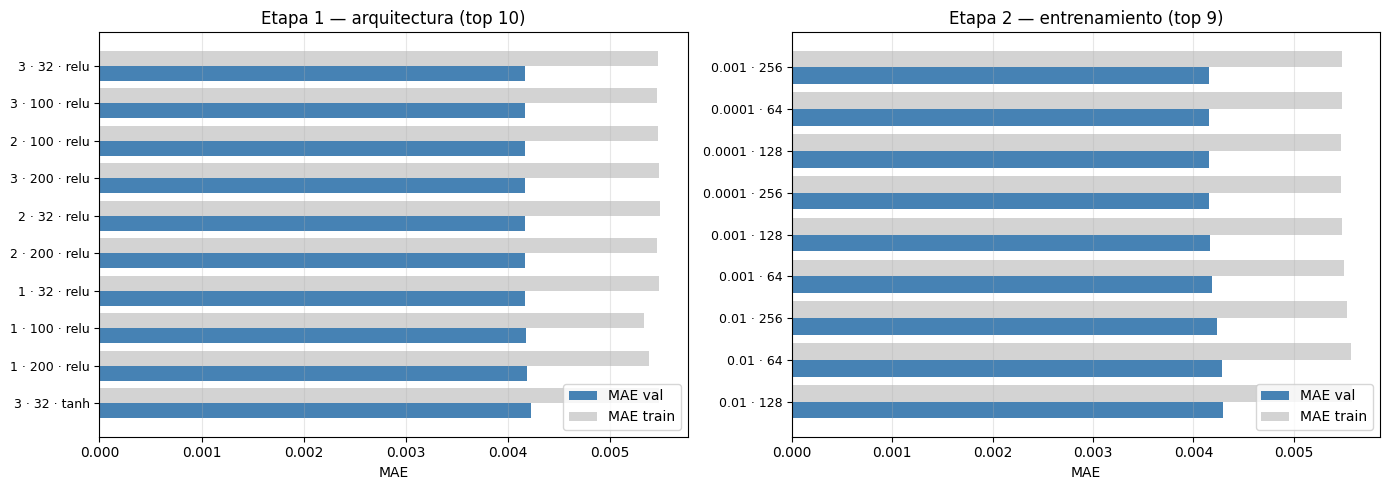

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

def plot_top(ax, df, label_cols, title, top=10):
    top_df = df.head(top).iloc[::-1]  # invertir para que el mejor quede arriba
    labels = top_df[label_cols].astype(str).agg(" · ".join, axis=1)
    ypos = np.arange(len(top_df))
    ax.barh(ypos - 0.2, top_df["MAE_val"],   height=0.4, label="MAE val",   color="steelblue")
    ax.barh(ypos + 0.2, top_df["MAE_train"], height=0.4, label="MAE train", color="lightgray")
    ax.set_yticks(ypos); ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel("MAE"); ax.set_title(title)
    ax.legend(loc="lower right"); ax.grid(True, axis="x", alpha=0.3)

plot_top(axes[0], results_arch_df,  ["hidden_layers", "neurons", "activation"],
         f"Etapa 1 — arquitectura (top 10)")
plot_top(axes[1], results_train_df, ["learning_rate", "batch_size"],
         f"Etapa 2 — entrenamiento (top {min(10, len(results_train_df))})")

plt.tight_layout(); plt.show()